# Advection of a step on an interval

Donea, J. & Huerta, A. (2003). *Finite Element Methods for Flow Problems*. $\S 3.11.4$

$$
\mathbb{S}
\begin{cases}
\Omega = [0, L_x] \\
u_0(x)=\text{H}(x_0-x) \\
u_{\text{I}}(x=0) = 1 & \text{inflow on left boundary} \\
\textbf{a}=a\,\textbf{e}_x & \text{constant velocity} \\
u_{\text{e}}(x,t) = \text{H}(x_0 + at - x)  & \text{exact solution} \\
\end{cases}
$$

In [1]:
import numpy as np
from lucifex.mesh import interval_mesh
from lucifex.fem import Constant
from lucifex.fdm import (CN, BE, FE,
    FiniteDifference, FunctionSeries, ConstantSeries,
    cfl_timestep)
from lucifex.solver import ibvp , BoundaryConditions, InitialBoundaryValueProblem
from lucifex.sim import run, Simulation
from lucifex.viz import plot_line, save_figure
from lucifex.utils import nested_dict, is_continuous_lagrange, as_index
from lucifex.pde.advection import advection, dg_advection


def create_simulation(
    element: tuple[str, int],
    Lx: float,
    Nx: int,    
    dt: float,
    D_adv: FiniteDifference,
    u_in: float,
    x0: float,
    a: float,
) -> InitialBoundaryValueProblem:
    mesh = interval_mesh(Lx, Nx)
    t = ConstantSeries(mesh, name='t', ics=0.0)
    dt = Constant(mesh, dt, name='dt')
    a = Constant(mesh, (a, ), name='a')
    u = FunctionSeries((mesh, *element), name='u', store=1)
    ics = lambda x: 1.0 * (x[0] <= x0) 
    bcs = BoundaryConditions(
        ('dirichlet', lambda x: x[0], u_in),
    )
    if is_continuous_lagrange(u.function_space):
        u_solver = ibvp(advection, ics, bcs)(u, dt, a, D_adv)
    else:
        u_solver = ibvp(dg_advection, ics)(u, dt, a, D_adv, bcs=bcs)
    return Simulation([u_solver], t, dt)


Lx = 1.0
Nx = 200
h = Lx / Nx
u_in = 1.0
x0 = 0.5 * Lx

a = 1.0
courant = 1.0
dt = cfl_timestep(a, h, courant)

elem_opts = [
    ('DP', 0),
    ('DP', 1),
    ('P', 1),
]
D_adv_opts = (FE, BE, CN)
simulations = nested_dict((FiniteDifference, tuple, Simulation))

for elem in elem_opts:
    for D_adv in D_adv_opts:
        simulations[elem][D_adv] = create_simulation(elem, Lx, Nx, dt, D_adv, u_in, x0, a)

n_stop = 30
for elem in elem_opts:
    for D_adv in D_adv_opts:
        run(simulations[elem][D_adv], n_stop) 

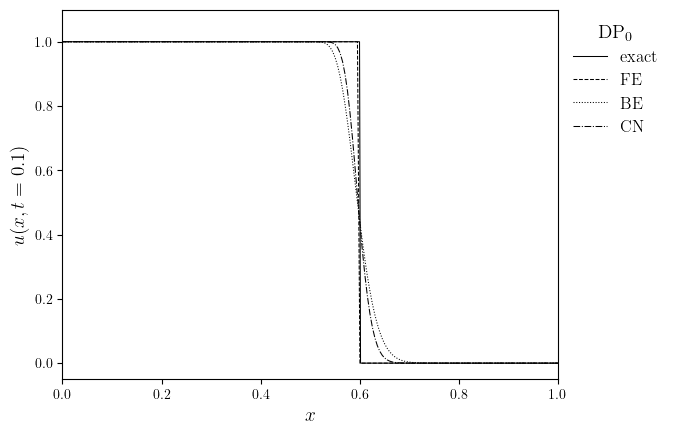

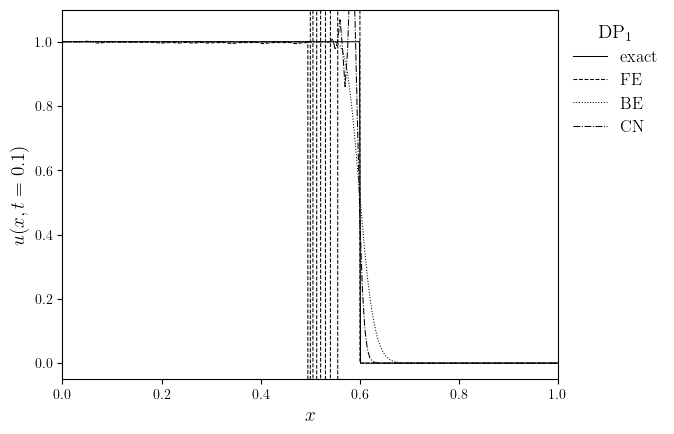

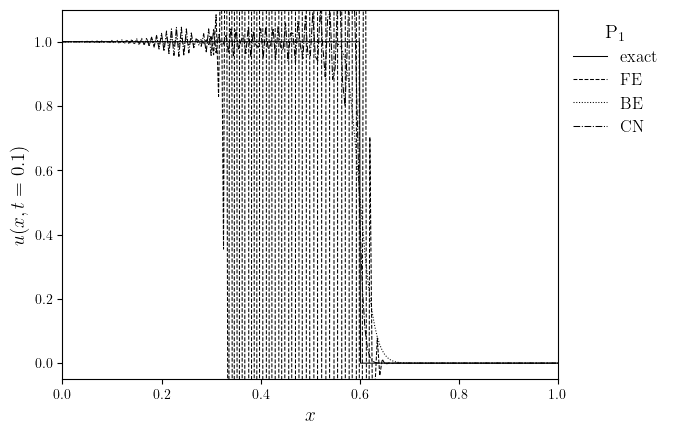

In [2]:
def exact_solution(
    x: np.ndarray, 
    t: float, 
    a: float,
    x0: float
) -> np.ndarray:
    u = np.zeros_like(x)
    u[x < x0 + a * t] = 1.0 
    return u

x = np.linspace(0, Lx, num=500)
t_target = dt * 20
ue = exact_solution(x, t_target, a, x0)

for elem in elem_opts:
    fam, deg = elem
    lines = [(x, ue)]
    legend_labels = ['exact']
    legend_title = f'{fam}$_{deg}$'
    for D_adv in D_adv_opts:
        u = simulations[elem][D_adv]['u']
        time_index = as_index(u.time_series, t_target, func=lambda x, y: np.isclose(x, y))
        lines.append(u.series[time_index])
        legend_labels.append(f'{D_adv}')
    fig, ax = plot_line(lines, legend_labels, legend_title, x_lims=x, x_label='$x$', y_label=f'$u(x,t={t_target})$')
    ax.set_ylim(-0.05, 1.1)
    save_figure(f'u(x,t={t_target})_{fam}{deg}')(fig)